<a href="https://colab.research.google.com/github/marcomunozq-miaad-uacj/Programacion1Semestre/blob/Matematicas1Sem/Problema4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preview (10 valores por generador):
rand0: [0.719268, 0.739813, 0.040915, 0.665954, 0.691949, 0.58084, 0.173188, 0.769168, 0.398188, 0.341197]
rand1: [0.702011, 0.466329, 0.834129, 0.545311, 0.286167, 0.753443, 0.201075, 0.479368, 0.899794, 0.845084]
rand2: [0.081102, 0.936398, 0.537119, 0.748861, 0.141693, 0.177686, 0.896935, 0.611528, 0.430668, 0.325379]
rand3: [0.011123, 0.789655, 0.203799, 0.565108, 0.745482, 0.746391, 0.869395, 0.526638, 0.024982, 0.539136]

Estadísticas (muestras grandes):
 rand0: media=0.500553, var=0.083088 (teórico U(0,1): media=0.5, var≈0.083333)
 rand1: media=0.501457, var=0.083198 (teórico U(0,1): media=0.5, var≈0.083333)
 rand2: media=0.499086, var=0.083325 (teórico U(0,1): media=0.5, var≈0.083333)
 rand3: media=0.499410, var=0.083267 (teórico U(0,1): media=0.5, var≈0.083333)


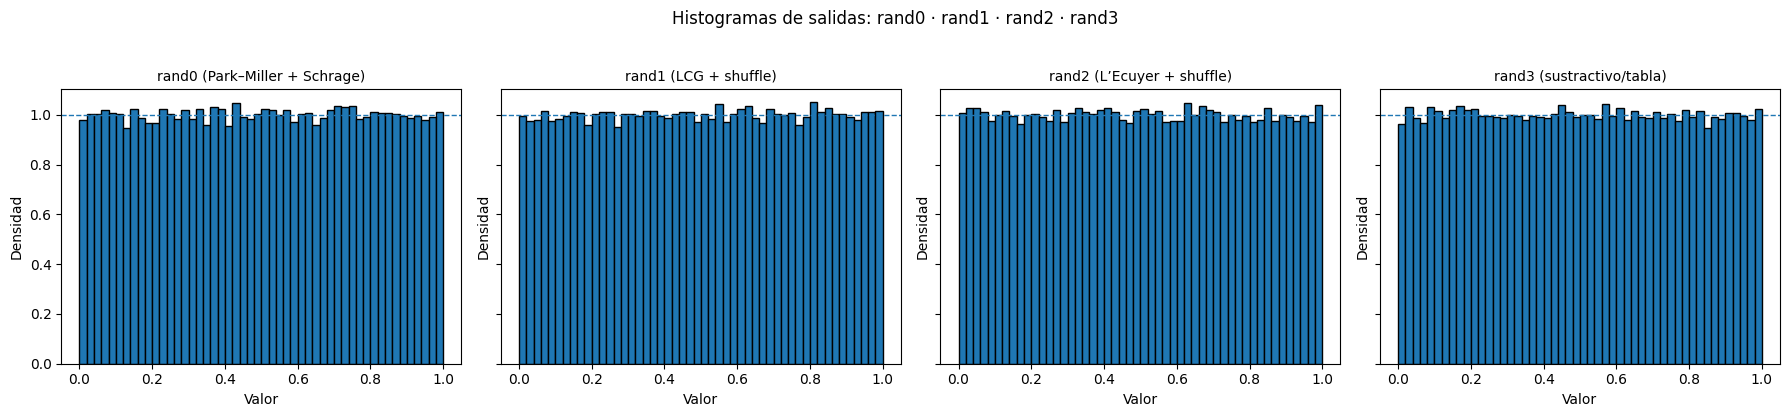

In [ ]:
# ============================================================
# Marco Antonio Muñoz Quiroz
# rand0, rand1, rand2, rand3
# ============================================================
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt
# ============================================================
# 1) RNGs (cada clase expone .rand() -> float en (0,1))
# ============================================================

class Rand0:
    """Park–Miller minimal LCG + Schrage (overflow-safe).
    Fórmula base: X_{n+1} = (a * X_n) mod m, U_{n+1} = X_{n+1} / m
    """

    def __init__(self, seed: int):
        # --- Constantes del LCG de Park–Miller (Minimal Standard) ---
        self.IA = 16807            # a = 16807 = 7^5 (multiplicador con buenas propiedades)
        self.IM = 2147483647       # m = 2^31 - 1 (primo de Mersenne; buen módulo)
        self.AM = 1.0 / self.IM    # factor de escala para mapear X a U en (0,1)
        # --- Constantes de Schrage (evita overflow en a*X_n) ---
        self.IQ = 127773           # floor(m / a)
        self.IR = 2836             # m % a
        # --- “MASK” opcional de NR: xor de la semilla para robustez frente a patrones triviales ---
        self.MASK = 123459876
        # --- Estado (semilla) ---
        self.seed = seed or 1      # evito seed=0; cualquier falsy lo cambio a 1

    def rand(self) -> float:
        # XOR opcional (NR): rompe patrones simples si se llama muy seguido con la misma seed desde fuera
        self.seed ^= self.MASK

        # Paso de Schrage: equivalente a (IA * seed) % IM pero sin overflow en 32 bits
        k = self.seed // self.IQ
        self.seed = self.IA * (self.seed - k * self.IQ) - self.IR * k
        if self.seed < 0:
            self.seed += self.IM   # aseguro que quede en [1, m-1]

        # Escalo a (0,1): U = X / m (nunca devuelve exactamente 0 ni 1)
        u = self.AM * self.seed

        # Des-XOR para dejar la semilla coherente para el siguiente paso
        self.seed ^= self.MASK
        return u


class Rand1:
    """LCG + Bays–Durham shuffle (tabla NTAB=32).
    Idea: usar una tabla de 32 valores para "barajar" la salida y reducir correlación de corto alcance.
    """

    def __init__(self, seed: int):
        # --- LCG base (igual que Rand0) ---
        self.IA = 16807
        self.IM = 2147483647
        self.AM = 1.0 / self.IM
        self.IQ = 127773
        self.IR = 2836
        # --- Parámetros del shuffle ---
        self.NTAB = 32                          # tamaño de la tabla de barajado
        self.NDIV = (self.IM - 1) // self.NTAB + 1  # particiona [1, m-1] en 32 segmentos
        self.EPS = 1.2e-7                       # pequeña cota para evitar devolver 1.0 exacto
        self.RNMX = 1.0 - self.EPS              # máximo permitido (≈ 0.99999988)
        # --- Estado ---
        self.seed = seed
        self.iv = [0] * self.NTAB               # tabla de barajado
        self.iy = 0                             # valor "barajado" en uso

        # --- Inicialización (NR): semilla <= 0 fuerza re-init para llenar la tabla iv ---
        if self.seed <= 0 or self.iy == 0:
            self.seed = 1 if self.seed == 0 else -abs(self.seed)  # NR usa semilla negativa para re-init
            for j in range(self.NTAB + 7, -1, -1):  # “warm-up” + llenado de tabla
                k = self.seed // self.IQ
                self.seed = self.IA * (self.seed - k * self.IQ) - self.IR * k
                if self.seed < 0:
                    self.seed += self.IM
                if j < self.NTAB:
                    self.iv[j] = self.seed     # guardo los últimos NTAB estados
            self.iy = self.iv[0]               # arranque del barajado

    def rand(self) -> float:
        # --- Paso LCG (Schrage) ---
        k = self.seed // self.IQ
        self.seed = self.IA * (self.seed - k * self.IQ) - self.IR * k
        if self.seed < 0:
            self.seed += self.IM

        # --- Bays–Durham shuffle ---
        j = self.iy // self.NDIV   # índice según el valor previo barajado
        self.iy = self.iv[j]       # tomo un valor de la tabla como salida intermedia
        self.iv[j] = self.seed     # reemplazo esa posición con el nuevo estado

        # --- Escala y recorte (evito retornar 1.0) ---
        u = self.AM * self.iy
        return self.RNMX if u > self.RNMX else u


class Rand2:
    """Dos LCG (L’Ecuyer) + shuffle (NTAB=32).
    Combina dos LCG con módulos distintos y aplica barajado para mejorar periodo y calidad estadística.
    """

    def __init__(self, seed: int):
        # --- Constantes de L’Ecuyer (clásicas en NR) ---
        self.IM1 = 2147483563          # primer módulo
        self.IM2 = 2147483399          # segundo módulo (ligeramente distinto)
        self.AM = 1.0 / self.IM1       # escala contra IM1
        self.IMM1 = self.IM1 - 1
        self.IA1 = 40014               # multiplicador 1
        self.IA2 = 40692               # multiplicador 2
        self.IQ1 = 53668               # Schrage 1: floor(IM1 / IA1)
        self.IQ2 = 52774               # Schrage 2: floor(IM2 / IA2)
        self.IR1 = 12211               # Schrage 1: IM1 % IA1
        self.IR2 = 3791                # Schrage 2: IM2 % IA2
        self.NTAB = 32
        self.NDIV = 1 + self.IMM1 // self.NTAB
        self.EPS = 1.2e-7
        self.RNMX = 1.0 - self.EPS
        # --- Estado ---
        self.seed = seed               # estado del primer LCG
        self.idum2 = 123456789         # estado del segundo LCG (NR sugiere inicializarlo)
        self.iy = 0
        self.iv = [0] * self.NTAB

        # --- Inicialización NR (semilla <= 0 fuerza re-init y llena la tabla iv) ---
        if self.seed <= 0:
            self.seed = 1 if self.seed == 0 else -abs(self.seed)
            self.idum2 = self.seed
            for j in range(self.NTAB + 7, -1, -1):
                # Paso LCG 1 con Schrage
                k = self.seed // self.IQ1
                self.seed = self.IA1 * (self.seed - k * self.IQ1) - k * self.IR1
                if self.seed < 0:
                    self.seed += self.IM1
                if j < self.NTAB:
                    self.iv[j] = self.seed
            self.iy = self.iv[0]

    def rand(self) -> float:
        # --- Avanzo el primer LCG (Schrage 1) ---
        k = self.seed // self.IQ1
        self.seed = self.IA1 * (self.seed - k * self.IQ1) - k * self.IR1
        if self.seed < 0:
            self.seed += self.IM1

        # --- Avanzo el segundo LCG (Schrage 2) ---
        k = self.idum2 // self.IQ2
        self.idum2 = self.IA2 * (self.idum2 - k * self.IQ2) - k * self.IR2
        if self.idum2 < 0:
            self.idum2 += self.IM2

        # --- Shuffle con resta (reduce correlación entre sucesivos) ---
        j = self.iy // self.NDIV
        self.iy = self.iv[j] - self.idum2   # combinación por diferencia
        self.iv[j] = self.seed              # actualizo tabla con el nuevo estado del LCG1
        if self.iy < 1:
            self.iy += self.IMM1            # mantengo en rango [1, IM1-1]

        # --- Escala y recorte ---
        u = self.AM * self.iy
        return self.RNMX if u > self.RNMX else u


class Rand3:
    """Método sustractivo (Knuth) con tabla MA[1..55].
    No usa multiplicaciones/mod; mantiene una tabla circular y genera por restas sucesivas.
    """

    def __init__(self, seed: int):
        # --- Constantes “grandes” y escala ---
        self.MBIG = 1000000000   # base para asegurar rango positivo amplio
        self.MSEED = 161803398   # semilla interna base (relacionada con φ ≈ 1.618e8)
        self.FAC = 1.0 / self.MBIG  # escala a (0,1)
        # --- Punteros cíclicos para recorrer la tabla de 55 enteros ---
        self.inext = 0
        self.inextp = 0
        # --- Tabla (NR usa índices 1..55; reservamos 56 y no usamos el 0) ---
        self.ma = [0] * 56

        # --- Inicialización estilo NR: llena ma[] con patrón de mezcla ---
        mj = abs(self.MSEED - abs(seed)) % self.MBIG
        self.ma[55] = mj
        mk = 1
        for i in range(1, 55):
            ii = (21 * i) % 55     # permutación tipo “salto” para distribuir posiciones
            self.ma[ii] = mk
            mk = mj - mk
            if mk < 0:
                mk += self.MBIG
            mj = self.ma[ii]
        # “Barajado” adicional: 4 pasadas restando valores separados
        for _ in range(4):
            for i in range(1, 56):
                self.ma[i] -= self.ma[1 + (i + 30) % 55]
                if self.ma[i] < 0:
                    self.ma[i] += self.MBIG
        # --- Punteros iniciales (separados ~31 posiciones) ---
        self.inext = 0
        self.inextp = 31

    def rand(self) -> float:
        # Avanzo punteros de forma circular en [1,55]
        self.inext += 1
        if self.inext == 56:
            self.inext = 1
        self.inextp += 1
        if self.inextp == 56:
            self.inextp = 1

        # Resta sustractiva (núcleo del método); mantengo positivo con MBIG si hace falta
        mj = self.ma[self.inext] - self.ma[self.inextp]
        if mj < 0:
            mj += self.MBIG
        self.ma[self.inext] = mj  # retroalimento la tabla (memoria deslizante)

        # Escalo a (0,1)
        return mj * self.FAC


# ============================================================
# 2) Utilidades (muestreo, resumen, gráficos)
# ============================================================

def sample_rng(rng, n: int) -> List[float]:
    """Devuelve n valores Uniforme(0,1) generados por rng.rand().
    Nota: usar una INSTANCIA DEDICADA si no quieres “consumir” el estado de otra.
    """
    return [rng.rand() for _ in range(n)]

def describe(name: str, data: List[float]) -> None:
    """Imprime media y varianza y las compara con U(0,1)."""
    arr = np.array(data, dtype=float)
    print(f"{name:>6s}: media={arr.mean():.6f}, var={arr.var():.6f} "
          f"(teórico U(0,1): media=0.5, var≈0.083333)")

def plot_side_by_side(datasets: List[Tuple[str, List[float]]],
                      bins: int = 50,
                      filename: str = "rng_histograms_side_by_side.png") -> None:
    """Dibuja 4 histogramas en una sola fila y guarda el PNG.
    - sharex/sharey para comparar distribuciones en la misma escala.
    - línea horizontal f(x)=1 (densidad de la U(0,1)) como referencia visual.
    """
    fig, axes = plt.subplots(nrows=1, ncols=len(datasets), figsize=(18, 4),
                             sharex=True, sharey=True)
    for ax, (title, data) in zip(axes, datasets):
        ax.hist(data, bins=bins, range=(0.0, 1.0), density=True, edgecolor="black")
        ax.axhline(1.0, linestyle="--", linewidth=1)  # densidad teórica U(0,1)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Valor")
        ax.set_ylabel("Densidad")
    fig.suptitle("Histogramas de salidas: rand0 · rand1 · rand2 · rand3",
                 fontsize=12, y=1.03)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


# ============================================================
# 3) Main (preview, muestreo grande, estadísticas y gráficos)
# ============================================================
if __name__ == "__main__":
    # --- Configuración global del experimento ---
    SEED = -13579       # semilla base; negativa fuerza init según NR
    N_PREVIEW = 10      # para inspeccionar rápidamente los primeros valores
    N_SAMPLE = 100000   # tamaño de muestra para histogramas y medias/varianzas

    # --- Instancias para “preview” (independientes del muestreo grande) ---
    r0, r1, r2, r3 = Rand0(SEED), Rand1(SEED), Rand2(SEED), Rand3(SEED)

    print("Preview (10 valores por generador):")
    print("rand0:", [round(r0.rand(), 6) for _ in range(N_PREVIEW)])
    print("rand1:", [round(r1.rand(), 6) for _ in range(N_PREVIEW)])
    print("rand2:", [round(r2.rand(), 6) for _ in range(N_PREVIEW)])
    print("rand3:", [round(r3.rand(), 6) for _ in range(N_PREVIEW)])

    # --- Nuevas instancias para muestreo grande ---
    # Usamos nuevas para NO “consumir” el estado de las de preview (consistencia).
    r0g, r1g, r2g, r3g = Rand0(SEED), Rand1(SEED), Rand2(SEED), Rand3(SEED)

    # --- Muestreo grande (Uniforme(0,1) teórica) ---
    data0 = sample_rng(r0g, N_SAMPLE)
    data1 = sample_rng(r1g, N_SAMPLE)
    data2 = sample_rng(r2g, N_SAMPLE)
    data3 = sample_rng(r3g, N_SAMPLE)

    # --- Estadísticas rápidas: deberían acercarse a media=0.5 y var≈1/12 ---
    print("\nEstadísticas (muestras grandes):")
    describe("rand0", data0)
    describe("rand1", data1)
    describe("rand2", data2)
    describe("rand3", data3)

    # --- Gráficas: 4 histogramas en una sola figura para comparación directa ---
    plot_side_by_side([
        ("rand0 (Park–Miller + Schrage)", data0),
        ("rand1 (LCG + shuffle)",         data1),
        ("rand2 (L’Ecuyer + shuffle)",    data2),
        ("rand3 (sustractivo/tabla)",     data3),
    ])
